In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import pandas as pd

# Load known exoplanets properties
How the planets were retrieved and the properties computed is detailed here: https://getagrip.streamlit.app/Derivation

In [2]:
orbits = pd.read_csv('Target-list-with-orbital-params-variable-inc-alb.csv')
orbits.columns

Index(['pl_name', 'pl_orbsmax', 'pl_orbper', 'pl_orbincl', 'pl_orbeccen',
       'pl_bmasse', 'pl_bmassj', 'st_mass', 'sy_dist', 'PlanetRadiuse',
       'pl_orblper', 'StarTeff', 'st_logg', 'st_met', 'StarRad', 'sy_imag',
       'sy_gaiamag', 'rastr', 'ra', 'decstr', 'dec', 'SpTNumber',
       'MaxProjectedSeparation_au', 'PhaseAtMaxProj', 'ContrastAtMaxProj',
       'MaxProjectedSeparation_au_inc90', 'MaxProjectedSeparation_au_inc10',
       'ContrastAtMaxProj_inc90_alb07', 'ContrastAtMaxProj_inc90_alb01',
       'ContrastAtMaxProj_inc10_alb07', 'ContrastAtMaxProj_inc10_alb01',
       'PhaseAtMaxProj_inc90', 'PhaseAtMaxProj_inc10',
       'ContrastAtMaxProj_alb07', 'ContrastAtMaxProj_alb01',
       'MaxProjectedSeparation_mas', 'MaxProjectedSeparation_mas_inc90',
       'MaxProjectedSeparation_mas_inc10', 'Note', 'cHZ_inner', 'cHZ_outer',
       'oHZ_inner', 'oHZ_outer', 'HZ', 'EarthEqInstell'],
      dtype='object')

# Generate the plot

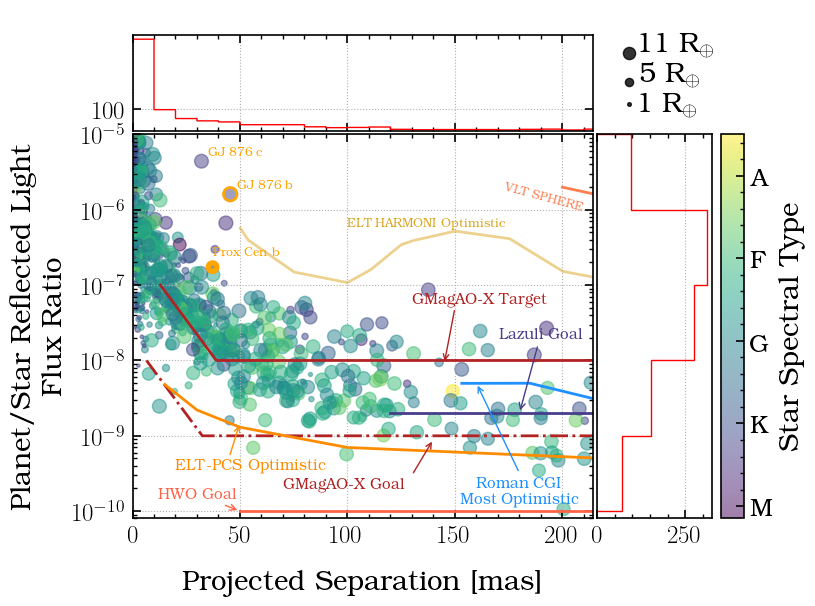

In [3]:

# Pick out Prox Cen b:
ind = [i for i in range(len(orbits)) if 'Prox' in orbits['pl_name'][i]]
ProxCen = orbits.loc[ind].reset_index(drop = True)
# Pick out GJ 876
ind = [i for i in range(len(orbits)) if 'GJ 876 b' in orbits['pl_name'][i]]
GJ876b = orbits.loc[ind].reset_index(drop = True)
ind = [i for i in range(len(orbits)) if 'GJ 876 c' in orbits['pl_name'][i]]
GJ876c = orbits.loc[ind].reset_index(drop = True)

import matplotlib as mpl

############## Get things to plot:
# Plot max projected separation in mas:
plotx = np.array(orbits['MaxProjectedSeparation_mas'])
# vs Contrast at that separation:
# I computed this at Ag = 0.3 but I want to publish it at 0.45 so I need to scale it
ploty = np.array(orbits['ContrastAtMaxProj'])  * 0.45/0.3
# Pull out relevant parameters:
# planet radius in earth radii:
rad = np.array(orbits['PlanetRadiuse'])
# host star spectral type number
SpTNum = np.array(orbits['SpTNumber'])
# viewing phase at max projected separation:
phases = np.array(orbits['PhaseAtMaxProj'])
# max projected separation in au:
# sepau = np.array(orbits['MaxProjectedSeparation_au'])


############## set some things for the plot:
xaxis_label = r'\[ \mathrm{Max\; Projected\; Separation}\; [mas]\]'
#annotation_text = r"$$\mathrm{For}\; i'\; filter, \;D = 25.4m\$$"
output_file_name = 'Cont-curves-vs-refl-planets.png'

# normalize colors:
colorby = SpTNum
norm = mpl.colors.Normalize(vmin=min(colorby), vmax=np.max(colorby))

################################### set up figure #######################################
fig = plt.figure()
ax = fig.add_gridspec(top=0.75, right=0.7).subplots()
radmult = 7 # radius multiplcative factor for marker sizes
ccfs = 9 # scatter plot label font size
ax.set_yscale('log')
xlim = 214
ax.set_xlim(0,xlim)
ylim = [8e-11,1e-5]
ax.set_ylim(*ylim)
ax.set_xlabel(r'Projected Separation [mas]', labelpad=15)
ax.set_ylabel('Planet/Star Reflected Light \n Flux Ratio')
ax.grid(ls=':')
savefig = True

############################ Main scatter plot ############################################
a = ax.scatter(plotx, ploty,# color='grey',
            c=colorby, cmap='viridis_r', 
               s=rad*radmult, alpha =0.5, 
               #norm=norm, edgecolor='black'
              )
## Highlight selected planets:
ax.scatter(ProxCen['MaxProjectedSeparation_mas'][0], ProxCen['ContrastAtMaxProj'][0] * 0.45/0.3,
         edgecolors = 'orange', lw=4, color='None')
ax.annotate('Prox Cen b', xy = (ProxCen['MaxProjectedSeparation_mas'][0], ProxCen['ContrastAtMaxProj'][0] * 0.45/0.3),
           xytext = (0,9), textcoords = 'offset points', fontsize=ccfs, color='orange')
ax.scatter(GJ876b['MaxProjectedSeparation_mas'][0], GJ876b['ContrastAtMaxProj'][0] * 0.45/0.3,
         edgecolors = 'orange', lw=2, color='None', s=GJ876b['PlanetRadiuse'][0]*radmult)
ax.annotate('GJ 876 b', xy = (GJ876b['MaxProjectedSeparation_mas'][0], GJ876b['ContrastAtMaxProj'][0] * 0.45/0.3),
           xytext = (5,5), textcoords = 'offset points', fontsize=ccfs, color='orange')
ax.annotate('GJ 876 c', xy = (GJ876c['MaxProjectedSeparation_mas'][0], GJ876c['ContrastAtMaxProj'][0] * 0.45/0.3),
           xytext = (5,5), textcoords = 'offset points', fontsize=ccfs, color='orange')


############################### contrast curves ######################################


plot_roman_curve = True
plot_lazuli_curve = True
plot_hwo_curve = True
plot_vlt_sphere = True
plot_gravity = False
plot_hst_stis = False
plot_harmoni = True
plot_gmagaox_target = True
plot_gmagaox_goal = True
plot_pcs_G2Vstar = True
plot_pcs_M3Vstar = False

lw1 = 2 # curve line width

######### Roman CGI:
# Contrast curves from https://github.com/nasavbailey/DI-flux-ratio-plot
cons_mode = '_opti' # I am chosing to plot the most optimistic curve but the other curves are also included in this repo
datapath = ''
fname = datapath+'Roman_pred_imaging_long'+cons_mode+'.txt'

from astropy.io import ascii
d_tel = 2.4 * u.m
dat = ascii.read(fname)
dat['lambda'].unit = u.nm
dat['contr_snr5'] = dat['contr']*5/dat['SNR']
dat['Rho(as)'] = dat['l/D'] * (dat['lambda'] / d_tel).decompose()*206265

romancolor = 'dodgerblue'

if plot_roman_curve:
    ax.plot(dat['Rho(as)']*1000, dat['contr_snr5'], color=romancolor, linewidth=lw1, linestyle='-', label='')
    txt = ax.text(180, 3e-10, \
        'Roman CGI \n Most Optimistic', color=romancolor, weight='bold',\
        horizontalalignment='center', verticalalignment='top', fontsize=ccfs+2, clip_on=False)
    ax.annotate("", xytext=(180, 3.2e-10), xy=(160, 5e-9),
                arrowprops=dict(arrowstyle="->", color=romancolor))


########## Lazuli: 
# From https://arxiv.org/html/2601.02556v1 Fig 11
lazulicolor = 'darkslateblue'
if plot_lazuli_curve:
    ax.plot([120,600], [2e-9,2e-9], color=lazulicolor, lw=lw1)
    ax.annotate("Lazuli Goal", xytext=(190, 2e-8), xy=(180, 2e-9),
                arrowprops=dict(arrowstyle="->", color=lazulicolor), fontsize=ccfs+2, color=lazulicolor, ha='center')

########## HWO: 

if plot_hwo_curve:
    ax.plot([50,500], [1e-10,1e-10], color='tomato', lw=lw1)
    ax.annotate("HWO Goal", xytext=(30, 1.5e-10), xy=(50, 1e-10),
                arrowprops=dict(arrowstyle="->", color='tomato'), fontsize=ccfs+2, color='tomato', ha='center')

########## VLT sphere:
# from https://github.com/nasavbailey
sphere_color = 'coral'
fname = datapath+'SPHERE_Vigan.txt'
a_SPHERE = ascii.read(fname)
a_SPHERE['Contrast'] = 10**(-0.4*a_SPHERE['delta'])

# manually split into IFS and IRDIS, at 0.7", as per documentation.
idx_yjh = a_SPHERE['Rho(as)'] <= 0.7 # IFS YJH
idx_k12 = a_SPHERE['Rho(as)'] >= 0.7  # IRDIS K1-K2

if plot_vlt_sphere:
    ax.plot(a_SPHERE['Rho(as)'][idx_yjh]*1000, a_SPHERE['Contrast'][idx_yjh], \
        color=sphere_color, linewidth=lw1, label='')
    ax.plot(a_SPHERE['Rho(as)'][idx_k12]*1000, a_SPHERE['Contrast'][idx_k12], \
        color=sphere_color, linewidth=lw1, label='')
    ax.text(210, 2.5E-6, 'VLT SPHERE', color=sphere_color, horizontalalignment='right', \
        verticalalignment='top', fontsize=ccfs, rotation = -15)

############ VLT Gravity:
# from https://github.com/nasavbailey
gravity_color = 'firebrick'
fname = datapath+'GRAVITY_pourre.txt'
a_GRAV = ascii.read(fname)
if plot_gravity:
    ax.plot(a_GRAV['Separation[mas]'],a_GRAV['K_band_contrast'],color=gravity_color,linewidth=lw1,label='')
    txt = 'VLTI GRAVITY'
    ax.text(0.05*1000,1.1*10**-4.6,txt,color=gravity_color,horizontalalignment='left',va='top',rotation=-10,fontsize=ccfs)

############ HST STIS:
# from https://github.com/nasavbailey
hst_color = 'cadetblue'
if plot_hst_stis:
    fname = datapath+'HST_STIS.txt'
    a_STIS = ascii.read(fname)
    ax.plot(a_STIS['Rho(as)']*1000,a_STIS['KLIP_Contr'],color=hst_color,\
        linewidth=lw1,label='')
    ax.text(0.2*1000,7*10**-5.2,'HST STIS',color=hst_color,horizontalalignment='left',va='center',rotation=-25,fontsize=ccfs)

############ ELT Harmoni:
# From https://ui.adsabs.harvard.edu/abs/2021A%26A...652A..67H/abstract Fig 7.
range_x = np.array((0.03, 1))
pessimistic_y = np.array((1E-5, 1E-8))
optimistic_y=np.array((1E-8, 1E-9))
if plot_harmoni:
    harmoni_color = 'goldenrod'
    # ax.plot(range_x*1000, pessimistic_y, color=c_h, linestyle='--', linewidth=lw1, alpha=0.5)
    # ax.plot(range_x*1000, optimistic_y, color=c_h, linestyle='-', linewidth=lw1, alpha=0.5)
    #ax.fill_between(range_x*1000, pessimistic_y, optimistic_y, color=c_h, alpha=0.1)

    # ax.text(230, 10E-9, 'ELT NIR Optimistic', color=c_h, horizontalalignment='left',\
    #     verticalalignment='top', fontsize=ccfs, rotation = -2)
    # ax.text(230, 3.8E-6, 'ELT NIR Pessimistic', color=c_h, horizontalalignment='left',\
    #     verticalalignment='top', fontsize=ccfs, rotation = -8)
    h = pd.read_csv('ELT-Harmoni-H-Optimistic.csv', comment='#')
    ax.plot(h['mas'], 10**(-0.4*h['mags']),color=harmoni_color, linestyle='-', linewidth=lw1, alpha=0.5)
    ax.text(100, 0.8e-6, 'ELT HARMONI Optimistic', color=harmoni_color, horizontalalignment='left',\
        verticalalignment='top', fontsize=ccfs, rotation = -0)

############## GMagAO-X:
# from Jared Males, private comm.
gmagaox_color = 'firebrick'
gmtlod = 0.2063*(0.8/25.4)*(u.arcsec).to(u.mas)
if plot_gmagaox_target:
    gmagaox_target = np.array([[2,6,100],[1e-7, 1e-8, 1e-8]])
    
    ax.plot(gmagaox_target[0]*gmtlod, gmagaox_target[1], color=gmagaox_color, lw=lw1)
    ax.text(130, 8e-8, 'GMagAO-X Target', color=gmagaox_color, horizontalalignment='left',\
        verticalalignment='top', fontsize=ccfs+2, rotation = 0)
    ax.annotate("", xytext=(150, 5e-8), xy=(145, 0.9e-8),
                arrowprops=dict(arrowstyle="->", color=gmagaox_color))
if plot_gmagaox_goal:
    gmagaox_goal = np.array([[1,5,100],[1e-8, 1e-9, 1e-9]])
    ax.plot(gmagaox_goal[0]*gmtlod, gmagaox_goal[1], color=gmagaox_color, lw=lw1, ls='-.')
    ax.text(70, 2.8e-10, 'GMagAO-X Goal', color=gmagaox_color, horizontalalignment='left',\
        verticalalignment='top', fontsize=ccfs+2, rotation = 0, clip_on=False)
    ax.annotate("", xytext=(130, 3e-10), xy=(140, 0.9e-9),
                arrowprops=dict(arrowstyle="->", color=gmagaox_color))

################ ELT-PCS:
# from ELT-PCS working package internal documents

# PCS curves from ballpark pdf
guidestar = np.array([1,3,5,7,9,10])
sep = np.array([15,30,50,100,300])
M3V = np.array([
    [1.6,0.7,0.5,0.2,0.1],
    [4.2,1.9,1.2,0.6,0.3],
    [10.1,4.4,3.0,1.5,0.7],
    [36.6,18.5,9.5,5.3,2.9],
    [128.5,59.5,42.0,23.9,15.1],
    [244.5,123.6,73.9,44.1,39.1]
])*1e-9 # for 10% throughput
M3V = M3V * np.sqrt(2.5)
G2V = np.array([
    [4.8,2.2,1.3,0.7,0.4],
    [13.0,4.9,3.3,1.6,1.0],
    [31.2,13.1,8.0,4.3,2.4],
    [104.5,54.4,29.2,15.0,9.5],
    [360.8,186.8,112.7,70.5,53.5],
    [778.1,361.9,252.1,151.6,112.0]
])*1e-9

pcs_color = 'darkorange'
if plot_pcs_G2Vstar:
    ax.plot(sep,G2V[0], color=pcs_color, lw=lw1, ls='-')
    ax.text(20, 5e-10, 'ELT-PCS Optimistic', color=pcs_color, horizontalalignment='left',\
        verticalalignment='top', fontsize=ccfs+2, rotation = 0, clip_on=False)
    ax.annotate("", xytext=(45, 5.2e-10), xy=(50, 1.5e-9),
                arrowprops=dict(arrowstyle="->", color=pcs_color))
if plot_pcs_M3Vstar:
    ax.plot(sep,M3V[0], color=pcs_color, lw=lw1, ls='-')
    ax.text(20, 5e-10, 'ELT-PCS Optimistic', color=pcs_color, horizontalalignment='left',\
        verticalalignment='top', fontsize=ccfs+2, rotation = 0, clip_on=False)
    ax.annotate("", xytext=(45, 5.2e-10), xy=(50, 1.5e-9),
                arrowprops=dict(arrowstyle="->", color=pcs_color))


######################## Radius legend #####################################################

x,y = xlim + (0.08*xlim),ylim[1]*12
ax.scatter(x,y, s = 11*radmult, color='black', alpha = 0.8, clip_on=False)
ax.annotate(r'11 R$_\oplus$', xy = (0.8,0.9), xytext = (0.8,0.925), xycoords='figure fraction',fontsize=20)
x,y = xlim + (0.08*xlim),ylim[1]*5
ax.scatter(x,y, s = 5*radmult, color='black', alpha = 0.8, clip_on=False)
ax.annotate(r'5 R$_\oplus$', xy = (0.8,0.85), xytext = (0.8,0.85+0.025), xycoords='figure fraction',fontsize=20)
x,y = xlim + (0.08*xlim),ylim[1]*2.5
ax.scatter(x,y, s = 1*radmult, color='black', alpha = 0.8, clip_on=False)
ax.annotate(r'1 R$_\oplus$', xy = (0.8,0.8), xytext = (0.8,0.8+0.025), xycoords='figure fraction',fontsize=20)


############################## Histograms ########################################################
histlw = 3
ax1 = ax.inset_axes([0,1.01,1,0.25])#, sharex=ax)
ax1.hist(plotx, histtype='step',lw=histlw, color='red', bins=np.arange(0,int(max(plotx)),10))
# vals, bins = np.histogram(plotx, bins=np.arange(0,int(max(plotx)),10))
# ax1.step(bins[:-1], vals, where='post',lw=histlw, color='red')
ax1.grid(ls=':')
ax1.set_xlim(0,xlim)
ax1.set_yticks([100])
ax1.set_xticklabels([])

ax2 = ax.inset_axes([1.01,0,0.25,1])
ax2.hist(np.log10(ploty), bins=np.arange(-10,-4,1), histtype='step',lw=histlw, color='red',orientation="horizontal")
# vals, bins = np.histogram(np.log10(ploty), bins=np.arange(-10,-4,1))
# ax2.barh(bins[:-1], vals,lw=histlw, color='red', align='edge')
ax2.set_ylim(bottom=np.log10(ylim[0]), top=np.log10(ylim[1]))
ax2.set_yticks([])
ax2.grid(ls=':')

############################# Color bar #########################################################
cbarax = ax.inset_axes([1.28,0,0.05,1])
fig.colorbar(a, cax=cbarax, orientation="vertical")
ticklabels = np.array(['B','A','F','G','K','M','L'])
cbarax.set_yticks(cbarax.get_yticks(),labels=ticklabels)
cbarax.set_ylim(np.min(colorby),np.max(colorby))
cbarax.set_ylabel('Star Spectral Type')
cbarax.invert_yaxis()


if savefig:
    plt.savefig(output_file_name, bbox_inches='tight')
